# Backtesting Trimestral 2025 — CNN Deep Conv1D

Análisis comparativo de **5 estrategias** de inversión sobre el universo de 23 activos durante 2025, con rebalanceo trimestral.

| Estrategia | Descripción |
|---|---|
| `cnn_top4_equal` | Top-4 por retorno predicho; pesos iguales |
| `cnn_top4_riskadjusted` | Top-4 por retorno predicho / volatilidad trailing |
| `cnn_top4_threshold` | Como Equal, pero solo activos con predicción > umbral; resto en cash |
| `bench_momentum` | Top-4 por retorno realizado en los últimos 90 días |
| `bench_equalweight` | Buy & Hold con peso igual en los 23 activos |

**Modelo**: CNN Deep Conv1D (input = 10 días, output = media de 90 días)
**Entrenamiento**: datos hasta 31-dic-2024 | **Test out-of-sample**: 2025

In [1]:
import os
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches

# Añadimos project root, model/cnn y scripts al path
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parents[1]
SCRIPTS_DIR = NOTEBOOK_DIR.parent / "scripts"

for _p in [str(PROJECT_ROOT), str(PROJECT_ROOT / "model" / "cnn"), str(SCRIPTS_DIR)]:
    if _p not in sys.path:
        sys.path.insert(0, _p)

os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import backtest_quarterly_momentum as bt

bt.setup(input_window=10, output_window=90)

Modelo no encontrado. Entrenando con train_cnn_in10_out90_to2024.run() ...

Training CNN Deep Conv1D | input=10 | output=90 | relative=False
Epoch 1/120
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2904 - mae: 0.2904 - val_loss: 0.0041 - val_mae: 0.0041 - learning_rate: 3.0000e-04
Epoch 2/120
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0139 - mae: 0.0139 - val_loss: 9.0771e-04 - val_mae: 9.0771e-04 - learning_rate: 3.0000e-04
Epoch 3/120
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0049 - mae: 0.0049 - val_loss: 9.0225e-04 - val_mae: 9.0225e-04 - learning_rate: 3.0000e-04
Epoch 4/120
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0028 - mae: 0.0028 - val_loss: 9.0306e-04 - val_mae: 9.0306e-04 - learning_rate: 3.0000e-04
Epoch 5/120
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0021 - mae: 0.0021 - val_loss: 9.0520e-04 - val_mae: 9.0520e-04 - learning_rate: 3.0000e-04
Epoch 6/120
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0018 - mae: 0.0018 - val_loss

/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Saved: /Users/higiniopaternaortiz/Master_BME/Neural-Networks-Forecasting/data/cnn/window_results/cnn_input10_output90_results.csv
Modelo cargado: data/cnn/saved_models/cnn_input10_output90_model.keras
Scaler ajustado sobre 12764 secuencias (10d × 23 activos).
Universo: 23 activos | 2025: 2025-01-02 → 2025-12-31 (250 días)
Periodos de rebalanceo (4):
  Q1: 2025-01-02 → 2025-03-31
  Q2: 2025-04-01 → 2025-06-30
  Q3: 2025-07-01 → 2025-09-30
  Q4: 2025-10-01 → 2025-12-31


## 1. Universo de activos

El universo está compuesto por **23 acciones del mercado estadounidense** (NYSE/NASDAQ).
Mostramos las estadísticas de retorno logarítmico diario durante el periodo de test (2025).

In [2]:
returns_2025 = bt.returns_full.loc["2025"]

print(f"Periodo out-of-sample : {returns_2025.index[0].date()} → {returns_2025.index[-1].date()}")
print(f"Días de trading       : {len(returns_2025)}")
print(f"\nActivos ({bt.n_assets}):")
print(bt.assets)

# Estadísticas de retorno diario en porcentaje
stats = (returns_2025.describe().T[["mean", "std", "min", "max"]] * 100).round(4)
stats.columns = ["Media diaria (%)", "Vol. diaria (%)", "Mínimo (%)", "Máximo (%)"]
display(stats.sort_values("Media diaria (%)", ascending=False))

Periodo out-of-sample : 2025-01-02 → 2025-12-31
Días de trading       : 250

Activos (23):
['AEP', 'BA', 'CAT', 'CNP', 'CVX', 'DIS', 'DTE', 'ED', 'GD', 'GE', 'HON', 'HPQ', 'IBM', 'IP', 'JNJ', 'KO', 'KR', 'MMM', 'MO', 'MRK', 'MSI', 'PG', 'XOM']


,Media diaria (%),Vol. diaria (%),Mínimo (%),Máximo (%)
Ticker,,,,
GE,0.2477,1.9178,-11.7617,10.0466
CAT,0.1888,2.0022,-9.0315,11.0061
JNJ,0.1554,1.2355,-7.8953,6.0090
IBM,0.1295,1.8824,-7.9301,12.1900
GD,0.1062,1.3355,-7.5513,6.5128
AEP,0.1030,1.2192,-4.3361,5.9034
MMM,0.0936,1.8608,-9.6305,8.4124
CNP,0.0852,1.0415,-3.4862,2.8763
BA,0.0817,2.3586,-11.0608,14.3010


## 2. Predicciones del CNN en cada rebalanceo

En cada fecha de rebalanceo el modelo recibe los **últimos 10 días de retornos** de los 23 activos
y predice la **media del log-return diario** en los próximos 90 días.

> **Interpretación del eje X**: la predicción se multiplica × 252 para aproximar un retorno
> anualizado (no es el retorno acumulado de 90 días). Los activos en azul son los 4 seleccionados.

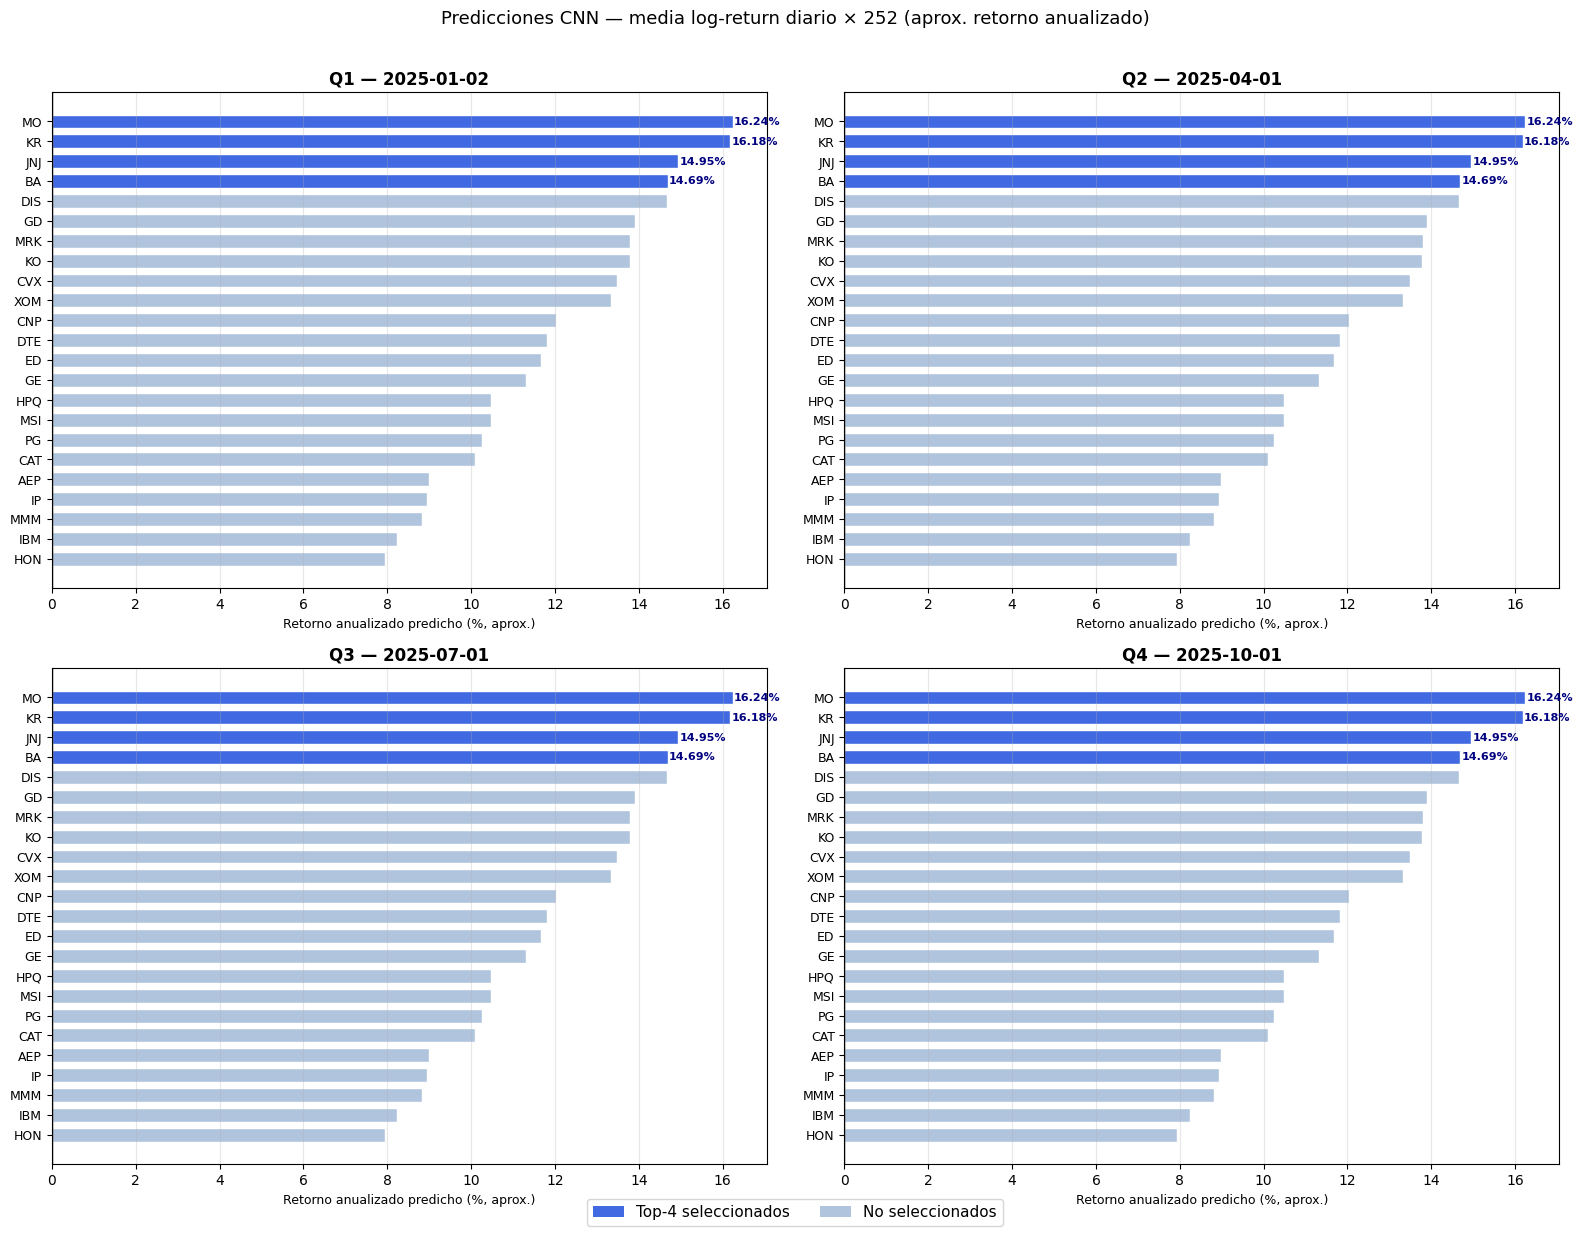

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for q_idx, (rb_date, ax) in enumerate(zip(bt.rebalance_dates, axes)):
    pred = bt.predict_at(rb_date)
    top4_idx = set(int(i) for i in np.argsort(pred)[::-1][:bt.N_TOP])
    order = list(np.argsort(pred))

    sorted_assets = [bt.assets[j] for j in order]
    pred_annual   = [float(pred[j]) * 252 * 100 for j in order]
    colors        = ["royalblue" if j in top4_idx else "lightsteelblue" for j in order]

    bars = ax.barh(sorted_assets, pred_annual, color=colors, edgecolor="white", height=0.7)
    ax.axvline(0, color="black", lw=1)
    ax.set_title(f"Q{q_idx + 1} — {rb_date.strftime('%Y-%m-%d')}", fontsize=12, fontweight="bold")
    ax.set_xlabel("Retorno anualizado predicho (%, aprox.)", fontsize=9)
    ax.grid(True, alpha=0.3, axis="x")
    ax.tick_params(axis="y", labelsize=9)

    for j_pos, (bar, val, j) in enumerate(zip(bars, pred_annual, order)):
        if j in top4_idx:
            ax.text(
                val + 0.03, bar.get_y() + bar.get_height() / 2,
                f"{val:.2f}%", va="center", fontsize=8, color="navy", fontweight="bold",
            )

legend_elems = [
    mpatches.Patch(facecolor="royalblue",     label="Top-4 seleccionados"),
    mpatches.Patch(facecolor="lightsteelblue", label="No seleccionados"),
]
fig.legend(handles=legend_elems, loc="lower center", ncol=2, fontsize=11, bbox_to_anchor=(0.5, -0.01))
fig.suptitle(
    "Predicciones CNN — media log-return diario × 252 (aprox. retorno anualizado)",
    fontsize=13, y=1.01,
)
plt.tight_layout()
plt.show()

## 3. Ejecución del backtest

Ejecutamos el backtest trimestral para las 5 estrategias y mostramos qué activos selecciona cada una en cada periodo.

In [4]:
ret_df, holdings = bt.run_backtest()

LABELS = {
    "model_top4_equal":        "CNN Equal",
    "model_top4_riskadjusted": "CNN Risk-Adj.",
    "model_top4_threshold":    "CNN Umbral",
    "bench_momentum":        "Momentum",
    "bench_equalweight":     "Equal Weight",
}

# Tabla de selección de activos por trimestre
quarter_names = [f"Q{i+1} ({d.strftime('%b %Y')})" for i, d in enumerate(bt.rebalance_dates)]
rows = {}
for name, label in LABELS.items():
    row = []
    for q in range(len(bt.rebalance_dates)):
        if q < len(holdings[name]):
            h = holdings[name][q]
            if name == "bench_equalweight":
                row.append("todos (1/23)")
            elif not h:
                row.append("cash")
            else:
                row.append(", ".join(sorted(h)))
        else:
            row.append("—")
    rows[label] = row

sel_df = pd.DataFrame(rows, index=quarter_names).T
display(sel_df)

Q1 (2025-01-02): pred top-4 = ['MO', 'KR', 'JNJ', 'BA']
Q2 (2025-04-01): pred top-4 = ['MO', 'KR', 'JNJ', 'BA']
Q3 (2025-07-01): pred top-4 = ['MO', 'KR', 'JNJ', 'BA']
Q4 (2025-10-01): pred top-4 = ['MO', 'KR', 'JNJ', 'BA']


,Q1 (Jan 2025),Q2 (Apr 2025),Q3 (Jul 2025),Q4 (Oct 2025)
CNN Equal,"BA, JNJ, KR, MO","BA, JNJ, KR, MO","BA, JNJ, KR, MO","BA, JNJ, KR, MO"
CNN Risk-Adj.,"ED, JNJ, KO, MO","DIS, JNJ, KO, MO","CNP, JNJ, KO, MO","DIS, JNJ, KO, MO"
CNN Umbral,"BA, JNJ, KR, MO","BA, JNJ, KR, MO","BA, JNJ, KR, MO","BA, JNJ, KR, MO"
Momentum,"CNP, DIS, HON, KR","BA, CNP, IBM, KO","BA, GD, GE, MO","CAT, GD, GE, JNJ"
Equal Weight,todos (1/23),todos (1/23),todos (1/23),todos (1/23)


## 4. Retorno acumulado

Evolución del valor de la cartera (base 100) a lo largo de 2025.
Las líneas verticales punteadas marcan las fechas de rebalanceo trimestral.

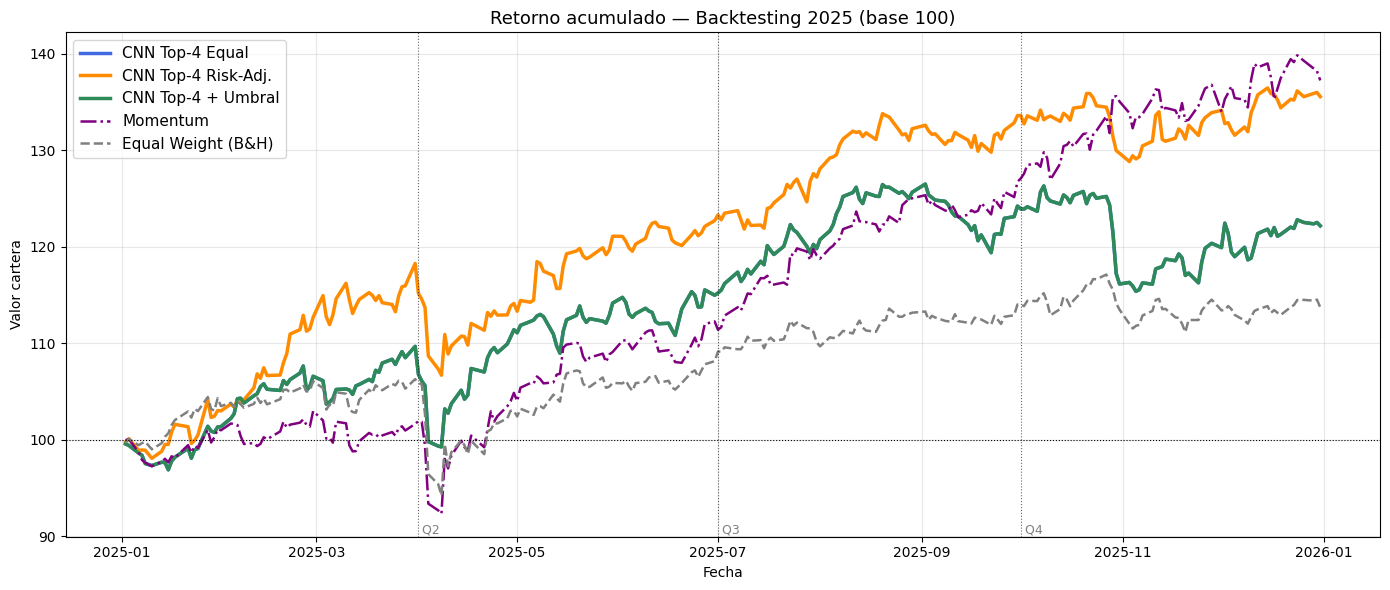

Retorno final (base 100):
  CNN Top-4 Equal               : 122.18  (+22.18 %)
  CNN Top-4 Risk-Adj.           : 135.57  (+35.57 %)
  CNN Top-4 + Umbral            : 122.18  (+22.18 %)
  Momentum                      : 137.25  (+37.25 %)
  Equal Weight (B&H)            : 113.73  (+13.73 %)


In [5]:
cum_value = ret_df.cumsum().apply(np.exp) * 100

STYLE = {
    "model_top4_equal":        dict(color="royalblue",  lw=2.5, ls="-",  label="CNN Top-4 Equal"),
    "model_top4_riskadjusted": dict(color="darkorange", lw=2.5, ls="-",  label="CNN Top-4 Risk-Adj."),
    "model_top4_threshold":    dict(color="seagreen",   lw=2.5, ls="-",  label="CNN Top-4 + Umbral"),
    "bench_momentum":        dict(color="purple",     lw=1.8, ls="-.", label="Momentum"),
    "bench_equalweight":     dict(color="gray",       lw=1.8, ls="--", label="Equal Weight (B&H)"),
}

fig, ax = plt.subplots(figsize=(14, 6))
for name, style in STYLE.items():
    ax.plot(cum_value.index, cum_value[name], **style)

for i, rb in enumerate(bt.rebalance_dates[1:], start=2):
    ax.axvline(rb, color="black", lw=0.8, ls=":", alpha=0.6)
    ax.text(rb, ax.get_ylim()[0], f" Q{i}", fontsize=9, color="gray", va="bottom")

ax.axhline(100, color="black", lw=0.8, ls=":")
ax.set_title("Retorno acumulado — Backtesting 2025 (base 100)", fontsize=13)
ax.set_xlabel("Fecha")
ax.set_ylabel("Valor cartera")
ax.legend(fontsize=11, loc="upper left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Retorno final (base 100):")
for name, style in STYLE.items():
    final = float(cum_value[name].iloc[-1])
    print(f"  {style['label']:30s}: {final:.2f}  ({final - 100:+.2f} %)")

## 5. Métricas de rendimiento

| Métrica | Descripción |
|---|---|
| **Retorno total (%)** | Ganancia acumulada en 2025 |
| **Sharpe ratio** | Retorno ajustado por riesgo (rf = 4 % anual) |
| **Max Drawdown (%)** | Caída máxima desde un máximo histórico |
| **Turnover medio** | Fracción de activos cambiados entre trimestres (0 = sin cambios, 1 = cartera completamente nueva) |

,Retorno (%),Sharpe,Max DD (%),Turnover
CNN Equal,22.18,1.081,-9.49,0.000
CNN Risk-Adj.,35.57,1.807,-9.79,0.500
CNN Umbral,22.18,1.081,-9.49,0.000
model_top4_propweights,21.71,1.059,-9.27,0.000
model_longshort,15.65,0.507,-10.72,0.000
Momentum,37.25,1.726,-10.33,1.333
bench_momentum_input,26.20,0.984,-16.39,1.667
Equal Weight,13.73,0.653,-11.33,0.000


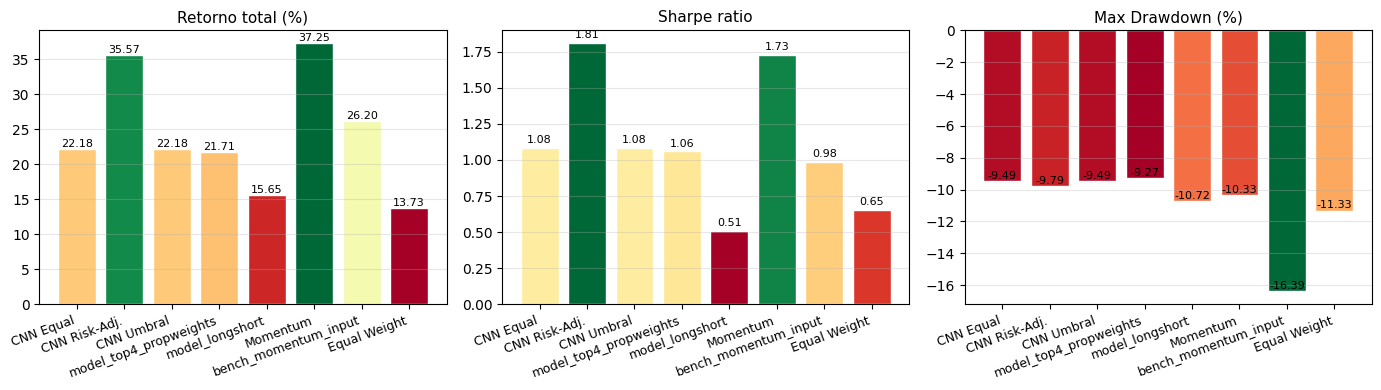

In [6]:
metrics_rows = [bt.compute_metrics(n, ret_df, holdings) for n in bt.STRATEGIES]
metrics = pd.DataFrame(metrics_rows).set_index("strategy")
metrics.index = [LABELS.get(n, n) for n in metrics.index]
metrics.columns = ["Retorno (%)", "Sharpe", "Max DD (%)", "Turnover"]

display(
    metrics.style
    .format({"Retorno (%)": "{:.2f}", "Sharpe": "{:.3f}", "Max DD (%)": "{:.2f}", "Turnover": "{:.3f}"})
    .background_gradient(subset=["Retorno (%)"], cmap="RdYlGn")
    .background_gradient(subset=["Sharpe"],      cmap="RdYlGn")
    .background_gradient(subset=["Max DD (%)"],  cmap="RdYlGn_r")
    .set_caption("Métricas de backtesting 2025")
)

# Gráfico de barras comparativo
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
cols   = ["Retorno (%)", "Sharpe", "Max DD (%)"]
cmaps  = ["RdYlGn", "RdYlGn", "RdYlGn_r"]
titles = ["Retorno total (%)", "Sharpe ratio", "Max Drawdown (%)"]

for ax, col, cmap_name, title in zip(axes, cols, cmaps, titles):
    vals   = metrics[col]
    cmap   = plt.get_cmap(cmap_name)
    norm   = plt.Normalize(vals.min(), vals.max())
    colors = [cmap(norm(v)) for v in vals]
    bars   = ax.bar(range(len(vals)), vals, color=colors, edgecolor="white")
    ax.set_xticks(range(len(vals)))
    ax.set_xticklabels(vals.index, rotation=20, ha="right", fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.grid(True, alpha=0.3, axis="y")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"{v:.2f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

## 6. Análisis de drawdown

El drawdown mide la caída porcentual respecto al máximo histórico de la cartera.
Es el indicador de riesgo más visible para un inversor real.

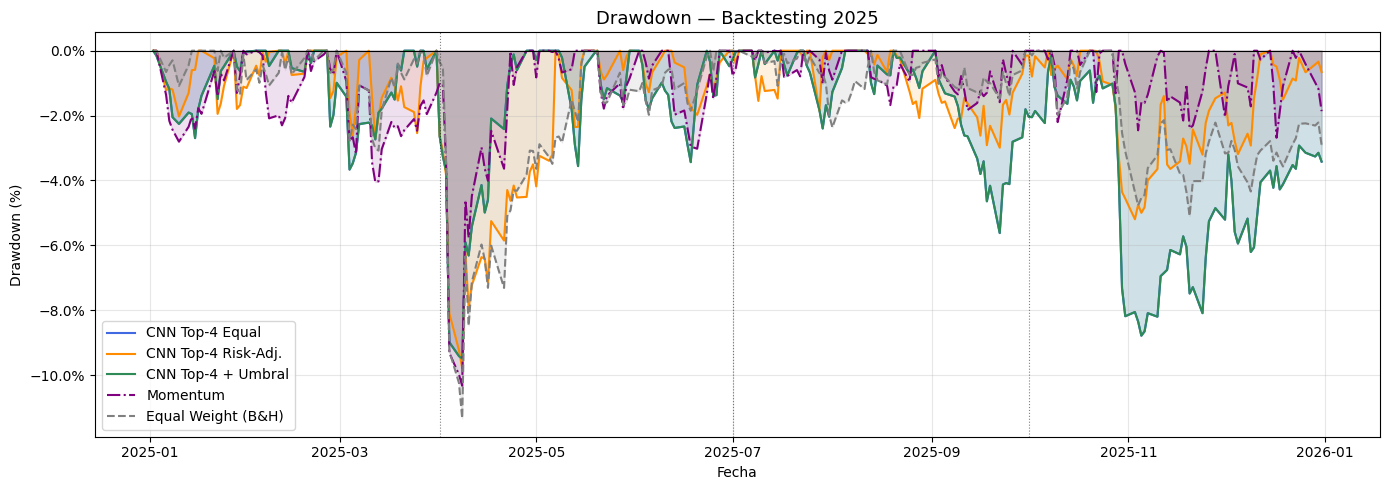

Max Drawdown por estrategia:
  CNN Top-4 Equal               : -9.49 %
  CNN Top-4 Risk-Adj.           : -9.79 %
  CNN Top-4 + Umbral            : -9.49 %
  Momentum                      : -10.33 %
  Equal Weight (B&H)            : -11.33 %


In [7]:
fig, ax = plt.subplots(figsize=(14, 5))

for name, style in STYLE.items():
    cum = ret_df[name].cumsum().apply(np.exp)
    dd  = (cum - cum.cummax()) / cum.cummax() * 100
    ax.fill_between(dd.index, dd, 0, alpha=0.12, color=style["color"])
    ax.plot(dd.index, dd, lw=1.5, color=style["color"], ls=style["ls"], label=style["label"])

for rb in bt.rebalance_dates[1:]:
    ax.axvline(rb, color="black", lw=0.8, ls=":", alpha=0.5)

ax.axhline(0, color="black", lw=0.8)
ax.set_title("Drawdown — Backtesting 2025", fontsize=13)
ax.set_xlabel("Fecha")
ax.set_ylabel("Drawdown (%)")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100, decimals=1))
ax.legend(fontsize=10, loc="lower left")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Max Drawdown por estrategia:")
for name, style in STYLE.items():
    cum = ret_df[name].cumsum().apply(np.exp)
    dd  = (cum - cum.cummax()) / cum.cummax() * 100
    print(f"  {style['label']:30s}: {float(dd.min()):.2f} %")

## 7. Problemática observada: el CNN como predictor constante

### 7.1 El síntoma: selección estática de activos en cada rebalanceo

Las estrategias basadas en el CNN (`cnn_top4_equal` y `cnn_top4_threshold`) seleccionan **exactamente los mismos 4 activos (BA, JNJ, KR, MO) en los cuatro trimestres**, con independencia de las condiciones de mercado de cada fecha de rebalanceo. En la práctica, ambas estrategias equivalen a un **buy & hold concentrado en 4 valores fijos** durante todo 2025, con turnover = 0.

### 7.2 La causa raíz: predictor constante por pérdida MAE

Un test de predicciones realizado a posteriori ha revelado que el problema va más allá de la elección del target o de la longitud de la ventana de entrada: **el modelo asigna el mismo valor de predicción a cada activo en cualquier instante temporal**, independientemente del input que reciba.

Para verificarlo se alimentó el modelo con **100 ventanas de entrada temporalmente espaciadas** (sin solapamiento entre ellas) a lo largo de toda la serie histórica. La desviación estándar de las predicciones *a lo largo del tiempo*, calculada por activo, fue exactamente **0 en los 23 activos**: el modelo devuelve una constante fija por activo.

#### ¿Por qué converge el modelo a una constante?

La función de pérdida utilizada durante el entrenamiento es la **MAE (Mean Absolute Error)**, equivalente a la norma L1. A diferencia del MSE (norma L2), cuyo minimizador sin condicionamiento es la media, el minimizador de la MAE es la **mediana** de la distribución del target.

Cuando la señal predictiva en los inputs es débil —como suele ocurrir con retornos financieros diarios— el gradiente de la pérdida MAE no es suficiente para que el modelo aprenda a diferenciar periodos. El entrenamiento converge entonces a predecir, para cada activo, la mediana histórica de su retorno a 90 días: un valor fijo que minimiza globalmente la MAE pero que **ignora completamente la información temporal contenida en el input**.

El resultado directo en el backtest es que el ranking de activos predicho es idéntico trimestre a trimestre, los mismos 4 activos siempre encabezan la lista, y el rebalanceo trimestral no aporta ningún valor sobre una cartera estática.